# GENIE systematics: unfolding-era vs recent

Compare **older** GENIE products (what fed unfolding / `systematics-final`) with the
**newer** Aug24 `sel_mup` campaign (+ latest Ar23p disk).

**Old-era exclusions** (dropped from all old modes before lists / plots):
`EDepFSI_CoulombCCQE`, `EDepFSI_DecayAngMEC`, `EDepFSI_Norm*MEC*`, and
`ZExpPCAWeighter_*_D_ZExp_b*`.

**Sections**
1. Full knob lists per era (and per mode)
2. Per-mode totals (inspect §2 uncertainty curves only — no matrices)
3. Total GENIE + top 10 knobs (inspect §3 uncertainty curves only — no matrices)

Each uncertainty figure is **1×2**: left = older (unfolding), right = newer.

Helpers: `analysis_village.numucc_1p0pi.syst_genie_inspect`.


In [43]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from typing import Dict, Mapping, Optional

import matplotlib.pyplot as plt
import numpy as np

REPO = Path("/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana")
sys.path.insert(0, str(REPO))

from analysis_village.numucc_1p0pi.dataset_locations import PLOTS_BASE
from analysis_village.numucc_1p0pi.final_selected_evt_vars import CORE_SELECTED_EVT_VARIABLE_CONFIGS
from analysis_village.numucc_1p0pi.syst_genie_inspect import (
    DISTRIBUTED_MODE_ORDER,
    MODE_ORDER,
    all_knob_parts,
    assign_ar23p_knob_to_mode,
    assign_other_mode_knob_to_bucket,
    display_mode_name,
    frac_unc_pct,
    integrated_frac_unc_pct,
    iter_knob_cov_fracs,
    load_cov_mat_dict,
    load_groups,
    mode_totals_ar23p_distributed,
    mode_totals_ar23p_standalone,
    plot_frac_unc_breakdown,
    plot_mode_frac_unc,
    short_knob_label,
    strip_mode_prefix,
    sum_cov_fracs,
    top_n_knobs_by_integrated,
)

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
SYST_BASE = Path("/exp/sbnd/data/users/munjung/xsec/numucc_1p0pi")
FINAL_BASE = Path("/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final")
OUT_DIR = Path(PLOTS_BASE) / "genie_syst_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Newer: Aug24 sel_mup modes; prefer newest Ar23p disk when present.
_AR23P_NEW_CANDIDATES = [
    SYST_BASE / "syst_disk_sel_mup_20260912_Ar23p/GENIE/cov_mat_dict.pkl",
    SYST_BASE / "syst_disk_sel_mup_Aug24_Ar23p/GENIE/cov_mat_dict.pkl",
]
_ar23p_new = next((p for p in _AR23P_NEW_CANDIDATES if p.is_file()), _AR23P_NEW_CANDIDATES[0])

GROUP_SOURCES_NEW = {
    "CCQE": SYST_BASE / "syst_disk_sel_mup_Aug24_CCQE/GENIE/cov_mat_dict.pkl",
    "MEC": SYST_BASE / "syst_disk_sel_mup_Aug24_MEC/GENIE/cov_mat_dict.pkl",
    "RES": SYST_BASE / "syst_disk_sel_mup_Aug24_RES/GENIE/cov_mat_dict.pkl",
    "nonRES": SYST_BASE / "syst_disk_sel_mup_Aug24_nonRES/GENIE/cov_mat_dict.pkl",
    "DIS": SYST_BASE / "syst_disk_sel_mup_Aug24_DIS/GENIE/cov_mat_dict.pkl",
    "Other": SYST_BASE / "syst_disk_sel_mup_Aug24_Other/GENIE/cov_mat_dict.pkl",
    "Ar23p": _ar23p_new,
}

# Older: unfolding-era per-mode NPZs + May Ar23p (knob→var layout).
GROUP_SOURCES_OLD = {
    "CCQE": FINAL_BASE / "genie-CCQE/genie-CCQE_syst_dict.npz",
    "MEC": FINAL_BASE / "genie-MEC/genie-MEC_syst_dict.npz",
    "RES": FINAL_BASE / "genie-RES/genie-RES_syst_dict.npz",
    "nonRES": FINAL_BASE / "genie-nonRES/genie-nonRES_syst_dict.npz",
    "DIS": FINAL_BASE / "genie-DIS/genie-DIS_syst_dict.npz",
    "Other": FINAL_BASE / "genie-Other/genie-Other_syst_dict.npz",
    "Ar23p": Path(
        "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-genie-final"
        "/systematics-genie-Ar23p-final/genie-Ar23p_syst_dict.npz"
    ),
}

# Optional overrides, e.g. GENIE_CMP_OLD_CCQE=/path  GENIE_CMP_NEW_Ar23p=/path
for era, sources in (("OLD", GROUP_SOURCES_OLD), ("NEW", GROUP_SOURCES_NEW)):
    for mode in list(sources):
        env = os.environ.get(f"GENIE_CMP_{era}_{mode}")
        if env:
            sources[mode] = Path(env)

VARS = ["integrated", "tki-del_Tp", "tki-del_alpha", "tki-del_phi"]
COV_TYPES = ["rate", "xsec"]
SAVE_FIGS = True
FIG_DPI = 140
TOP_N_KNOBS = 10
ERA_LABELS = {"old": "Old", "new": "New"}

vc_by = {vc.var_save_name: vc for vc in CORE_SELECTED_EVT_VARIABLE_CONFIGS}
print("OUT_DIR =", OUT_DIR)
print("\n--- OLD ---")
for m, p in GROUP_SOURCES_OLD.items():
    print(f"  {m:7s} exists={Path(p).is_file()}  {p}")
print("\n--- NEW ---")
for m, p in GROUP_SOURCES_NEW.items():
    print(f"  {m:7s} exists={Path(p).is_file()}  {p}")


OUT_DIR = /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison

--- OLD ---
  CCQE    exists=True  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-CCQE/genie-CCQE_syst_dict.npz
  MEC     exists=True  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-MEC/genie-MEC_syst_dict.npz
  RES     exists=True  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-RES/genie-RES_syst_dict.npz
  nonRES  exists=True  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-nonRES/genie-nonRES_syst_dict.npz
  DIS     exists=True  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-DIS/genie-DIS_syst_dict.npz
  Other   exists=True  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-Other/genie-Other_syst_dict.npz
  Ar23p   exists=True  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-genie-final/systematics-genie-Ar23p-final/genie-Ar23p_syst_dict.npz

--- NEW ---
 

In [45]:
import re

from analysis_village.numucc_1p0pi.syst_genie_inspect import TOTAL_KEYS

# Old-era knobs to drop (May Ar23p NPZ mixed these with true Ar23p model knobs).
_OLD_EXCLUDE_EXACT = {
    "GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_CoulombCCQE",
    "GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_DecayAngMEC",
}
_OLD_EXCLUDE_RE = [
    re.compile(r"EDepFSI_Norm\w*MEC"),  # NormCCMEC, NormNCMEC, …
    re.compile(r"ZExpPCAWeighter_SBNNuSyst_multisigma_D_ZExp_b\d+"),
]


def is_excluded_old_knob(knob: str) -> bool:
    kn = str(knob)
    base = kn[: -len("_rate")] if kn.endswith("_rate") else kn
    if base in _OLD_EXCLUDE_EXACT:
        return True
    return any(rx.search(base) for rx in _OLD_EXCLUDE_RE)


def filter_cov_mat_dict(cov: dict, *, drop_pred) -> tuple[dict, list[str]]:
    """Drop knobs matching ``drop_pred``; recompute ``genie`` / ``genie_rate`` totals."""
    dropped: list[str] = []
    out: Dict[str, Dict[str, np.ndarray]] = {}
    for slug, row in cov.items():
        kept: Dict[str, np.ndarray] = {}
        for key, mat in row.items():
            if key in TOTAL_KEYS:
                continue
            base = key[: -len("_rate")] if key.endswith("_rate") else key
            if drop_pred(base):
                if not key.endswith("_rate") and base not in dropped:
                    dropped.append(base)
                continue
            kept[key] = np.asarray(mat, dtype=np.float64)
        tot_x = tot_r = None
        for key, mat in kept.items():
            if key.endswith("_rate"):
                tot_r = mat.copy() if tot_r is None else tot_r + mat
            else:
                tot_x = mat.copy() if tot_x is None else tot_x + mat
        if tot_x is not None:
            kept["genie"] = tot_x
        if tot_r is not None:
            kept["genie_rate"] = tot_r
        out[slug] = kept
    return out, sorted(dropped)


def legacy_ar23p_npz_to_cov_mat_dict(path: Path | str) -> dict:
    """May-era Ar23p NPZ is ``{knob: {var: {rate|xsec: {cov_frac,…}}}}``.

    Convert to the flat ``cov_mat_dict`` layout used by ``syst_genie_inspect``.
    """
    path = Path(path)
    z = np.load(path, allow_pickle=True)
    out: Dict[str, Dict[str, np.ndarray]] = {}
    for kn in z.files:
        cell = z[kn]
        by_var = cell.item() if hasattr(cell, "item") else cell
        if not isinstance(by_var, dict):
            continue
        for slug, pack in by_var.items():
            if not isinstance(pack, dict):
                continue
            row = out.setdefault(slug, {})
            for kind, suffix in (("xsec", ""), ("rate", "_rate")):
                if kind not in pack:
                    continue
                sub = pack[kind]
                cf = np.asarray(
                    sub["cov_frac"] if isinstance(sub, dict) else sub,
                    dtype=np.float64,
                )
                key = kn + suffix
                row[key] = cf
                tot_key = "genie_rate" if kind == "rate" else "genie"
                if tot_key not in row:
                    row[tot_key] = cf.copy()
                else:
                    row[tot_key] = row[tot_key] + cf
    return out


def load_groups_flexible(sources: Mapping[str, Path | str], *, label: str) -> dict:
    """Like ``load_groups``, but May Ar23p NPZ uses knob→var layout."""
    out = {}
    for mode, path in sources.items():
        path = Path(path)
        if not path.is_file():
            print(f"WARNING [{label}]: missing {mode}: {path}")
            continue
        if mode == "Ar23p" and path.suffix == ".npz":
            # Detect layout: var-keyed (standard) vs knob-keyed (May Ar23p).
            z = np.load(path, allow_pickle=True)
            first = z.files[0] if z.files else ""
            if first in ("integrated", "muon-p") or first.startswith("tki-"):
                cov = load_cov_mat_dict(path)
            else:
                cov = legacy_ar23p_npz_to_cov_mat_dict(path)
                print(f"loaded {mode} [{label}] (legacy knob→var NPZ): {path}")
                out[mode] = cov
                continue
        else:
            cov = load_cov_mat_dict(path)
        out[mode] = cov
        print(f"loaded {mode} [{label}]: {path}")
    return out


groups_old = load_groups_flexible(GROUP_SOURCES_OLD, label="old")
groups_new = load_groups_flexible(GROUP_SOURCES_NEW, label="new")
if not groups_old or not groups_new:
    raise FileNotFoundError("Need at least one mode for each era — check paths above")

# Apply old-era exclusions and recompute mode totals from remaining knobs.
_dropped_old: list[str] = []
for mode in list(groups_old):
    groups_old[mode], dropped = filter_cov_mat_dict(
        groups_old[mode], drop_pred=is_excluded_old_knob,
    )
    for kn in dropped:
        if kn not in _dropped_old:
            _dropped_old.append(kn)
print(f"\nOld-era excluded knobs ({len(_dropped_old)}):")
for kn in _dropped_old:
    print(f"  - {kn}")

common_vars = set.intersection(
    *(set(g.keys()) for g in list(groups_old.values()) + list(groups_new.values()))
)
plot_vars = [v for v in VARS if v in common_vars]
if not plot_vars:
    plot_vars = sorted(common_vars)
print("plot_vars:", plot_vars)


loaded CCQE [old]: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-CCQE/genie-CCQE_syst_dict.npz
loaded MEC [old]: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-MEC/genie-MEC_syst_dict.npz
loaded RES [old]: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-RES/genie-RES_syst_dict.npz
loaded nonRES [old]: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-nonRES/genie-nonRES_syst_dict.npz
loaded DIS [old]: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-DIS/genie-DIS_syst_dict.npz
loaded Other [old]: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-Other/genie-Other_syst_dict.npz
loaded Ar23p [old] (legacy knob→var NPZ): /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-genie-final/systematics-genie-Ar23p-final/genie-Ar23p_syst_dict.npz
loaded CCQE [new]: /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_sel_mup_Aug24_CCQE/GENIE/cov_mat_di

## 1. Knob lists

Full list of knobs present in each era (xsec keys on `integrated`), by mode,
then a set-difference summary.


In [46]:
def knobs_for_mode(groups: dict, mode: str, kind: str = "xsec") -> list[str]:
    if mode not in groups or "integrated" not in groups[mode]:
        return []
    return sorted(k for k, _ in iter_knob_cov_fracs(groups[mode]["integrated"], kind))


def print_knob_lists(groups: dict, era_name: str):
    print(f"\n{'=' * 72}")
    print(f"{era_name}")
    print("=" * 72)
    all_knobs = []
    for mode in MODE_ORDER:
        knobs = knobs_for_mode(groups, mode)
        all_knobs.extend(knobs)
        print(f"\n--- {mode} ({len(knobs)} knobs) ---")
        for kn in knobs:
            print(f"  {short_knob_label(kn):40s}  {kn}")
    print(f"\nTotal knob entries across modes: {len(all_knobs)}")
    return all_knobs


knobs_old = print_knob_lists(groups_old, ERA_LABELS["old"])
knobs_new = print_knob_lists(groups_new, ERA_LABELS["new"])

set_old, set_new = set(knobs_old), set(knobs_new)
print(f"\n{'=' * 72}")
print("Set difference (exact full names)")
print("=" * 72)
only_old = sorted(set_old - set_new)
only_new = sorted(set_new - set_old)
print(f"only in older: {len(only_old)}")
for kn in only_old:
    print(f"  - {kn}")
print(f"only in newer: {len(only_new)}")
for kn in only_new:
    print(f"  + {kn}")
print(f"in both (exact name): {len(set_old & set_new)}")



Old

--- CCQE (2 knobs) ---
  CoulombCCQE                               GENIEReWeight_SBN_v1_multisim_CoulombCCQE
  RPA CCQE                                  GENIEReWeight_SBN_v1_multisim_RPA_CCQE

--- MEC (3 knobs) ---
  DecayAngMEC                               GENIEReWeight_SBN_v1_multisigma_DecayAngMEC
  NormCCMEC                                 GENIEReWeight_SBN_v1_multisim_NormCCMEC
  NormNCMEC                                 GENIEReWeight_SBN_v1_multisim_NormNCMEC

--- RES (8 knobs) ---
  MaCCRES                                   GENIEReWeight_SBN_v1_multisigma_MaCCRES
  MaNCRES                                   GENIEReWeight_SBN_v1_multisigma_MaNCRES
  MvCCRES                                   GENIEReWeight_SBN_v1_multisigma_MvCCRES
  MvNCRES                                   GENIEReWeight_SBN_v1_multisigma_MvNCRES
  ThetaDelta2NRad                           GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad
  Theta Delta2Npi                           GENIEReWeight_SBN_v1_multisi

## 2. Per-mode totals (+ Ar23p treatments)

Same recipes as `systematics-genie-inspect.ipynb` §2 (uncertainty curves only):

1. **Standalone** — Ar23p is its own mode
2. **Distributed** — Ar23p / Other knobs remapped (QE / MEC / FSI / Other)

Each figure: **left = older**, **right = newer**.


Distributed assignment examples (newer):
  Other→FSI: 5 knobs (e.g. GENIEReWeight_SBN_v1_multisigma_FrAbs_pi)
  Other→Other: 4 knobs (e.g. GENIEReWeight_SBN_v1_multisigma_EtaNCEL)
  Ar23p→QE: 26 knobs (e.g. CCQETemplateReweight_SBN_v3_HFToCRPA_q0bin0)
  Ar23p→FSI: 13 knobs (e.g. GENIEReWeight_SBN_v3_FrG4HiE_N)
  Ar23p→MEC: 8 knobs (e.g. MECq0q3InterpWeighting_SBN_v3_SuSAToMar_MECResponse_q0bin0)
wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__standalone__rate__integrated.png


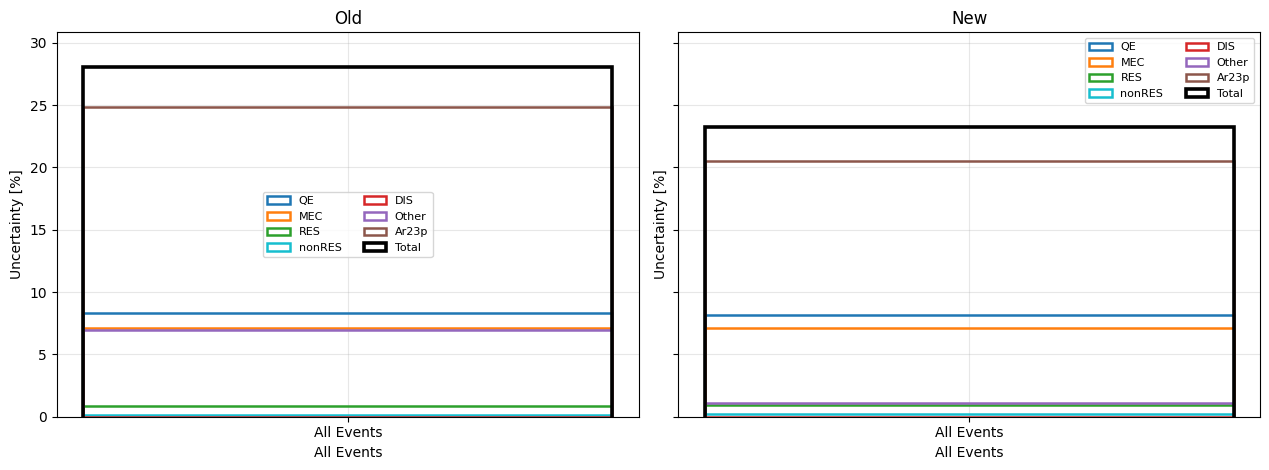

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__standalone__rate__tki-del_Tp.png


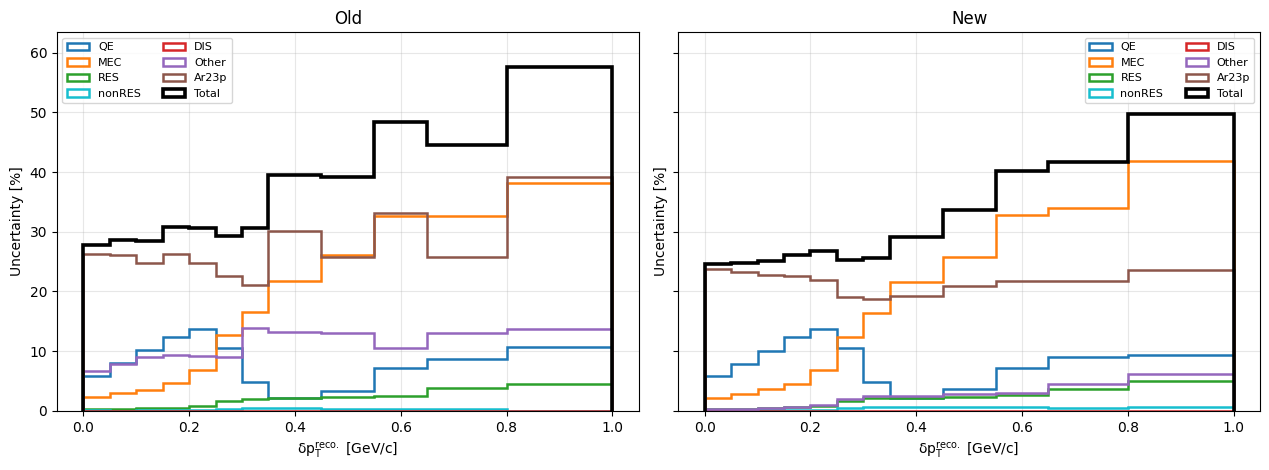

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__standalone__rate__tki-del_alpha.png


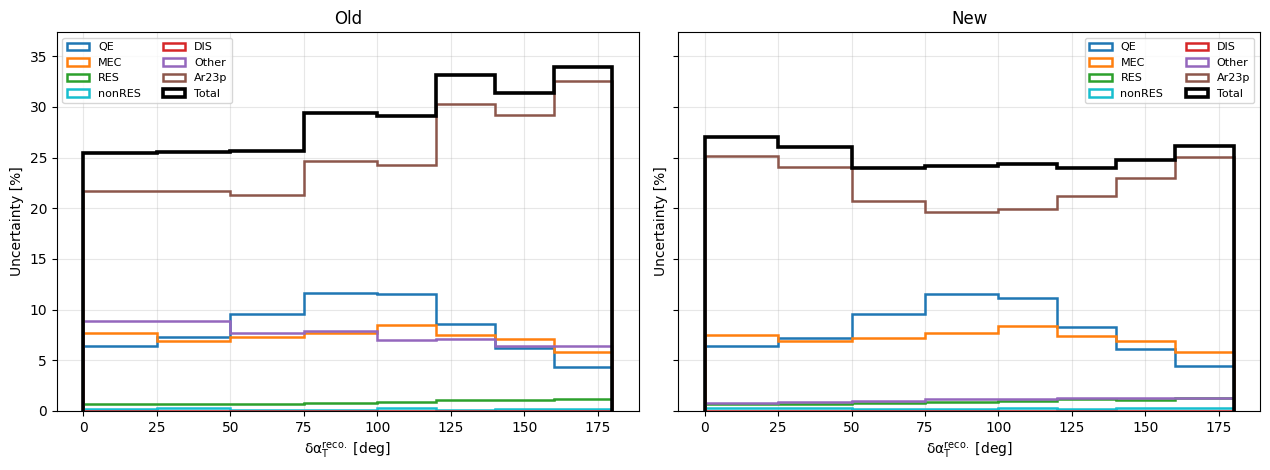

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__standalone__rate__tki-del_phi.png


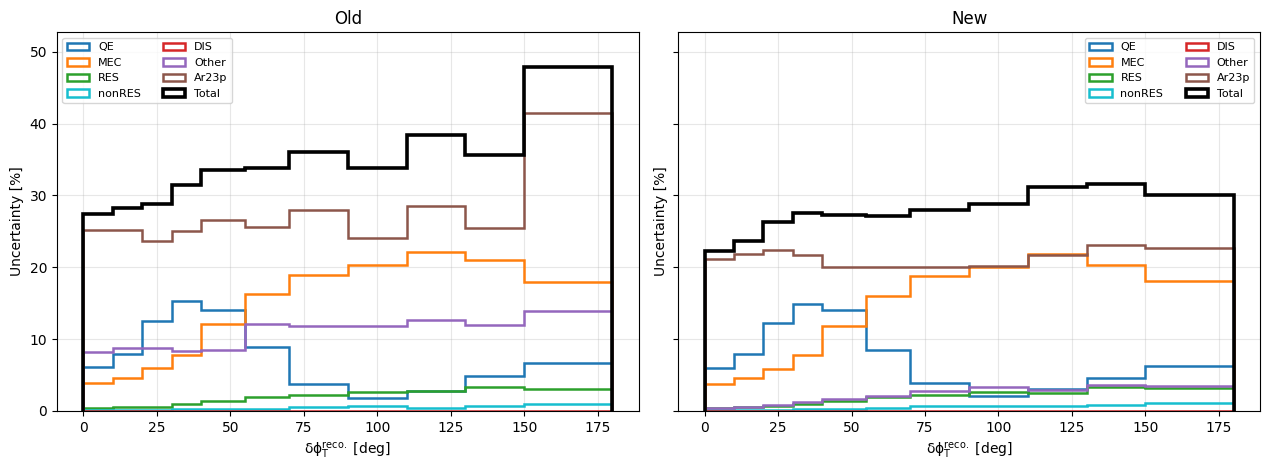

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__standalone__xsec__integrated.png


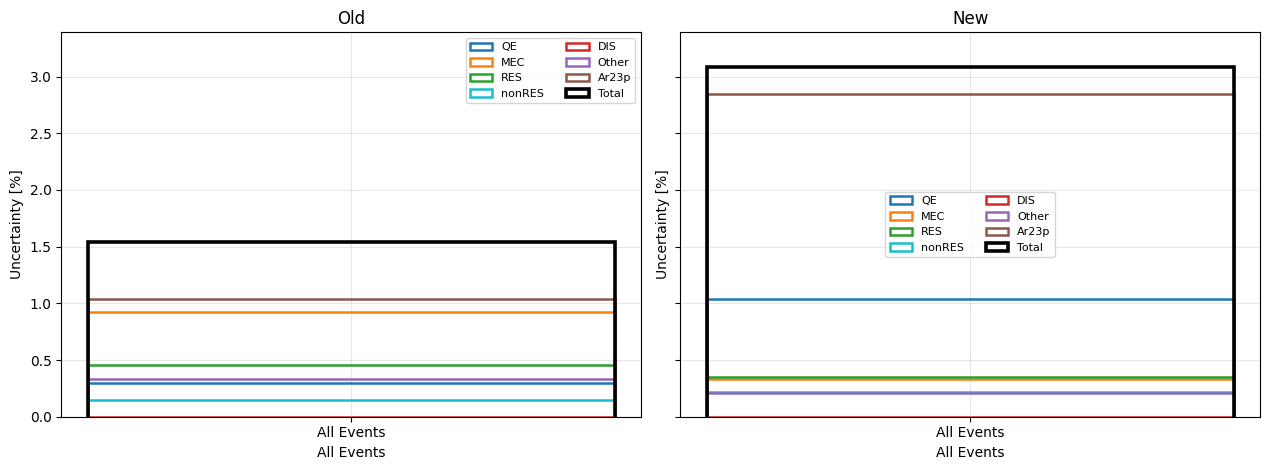

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__standalone__xsec__tki-del_Tp.png


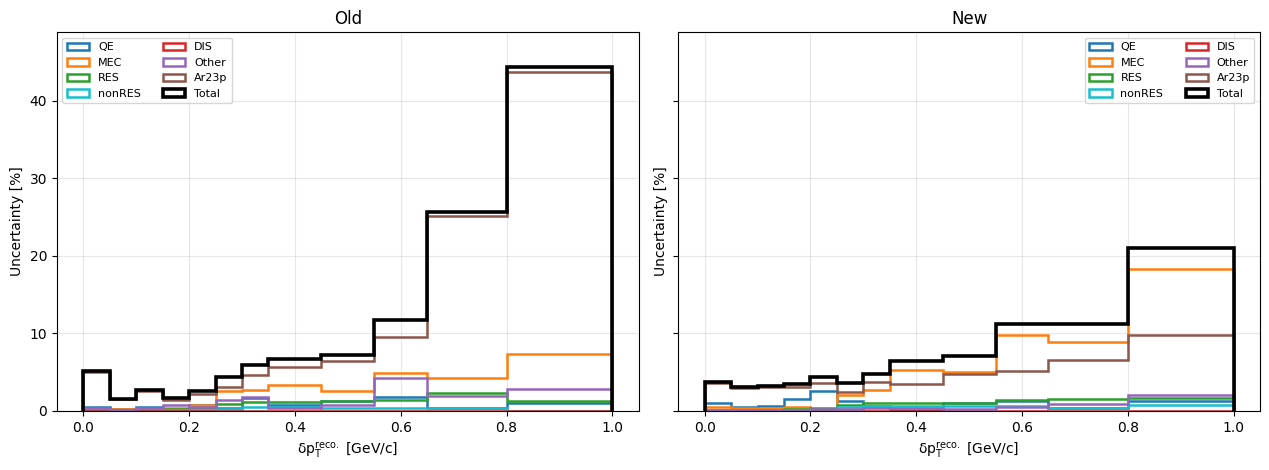

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__standalone__xsec__tki-del_alpha.png


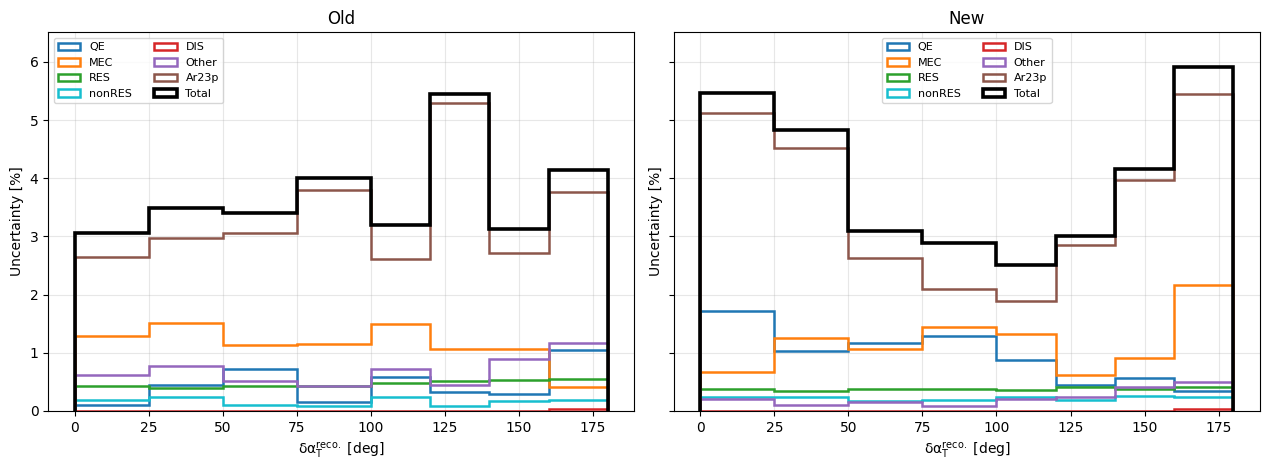

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__standalone__xsec__tki-del_phi.png


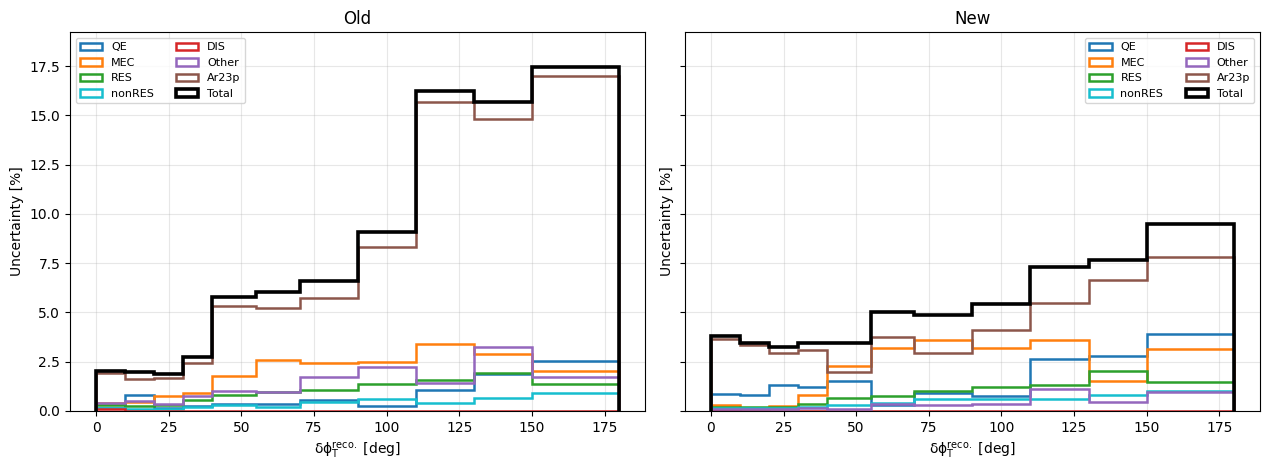

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__distributed__rate__integrated.png


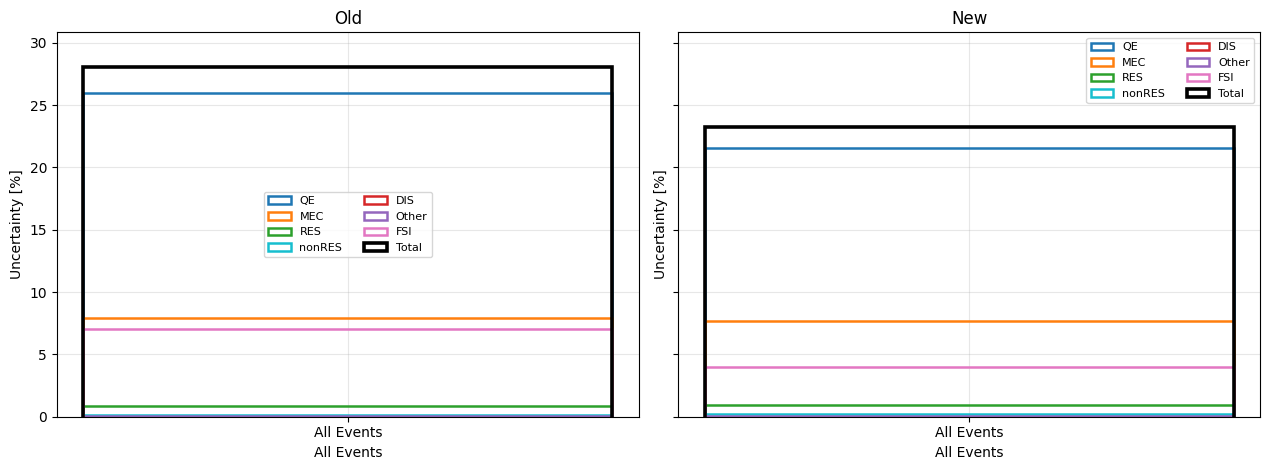

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__distributed__rate__tki-del_Tp.png


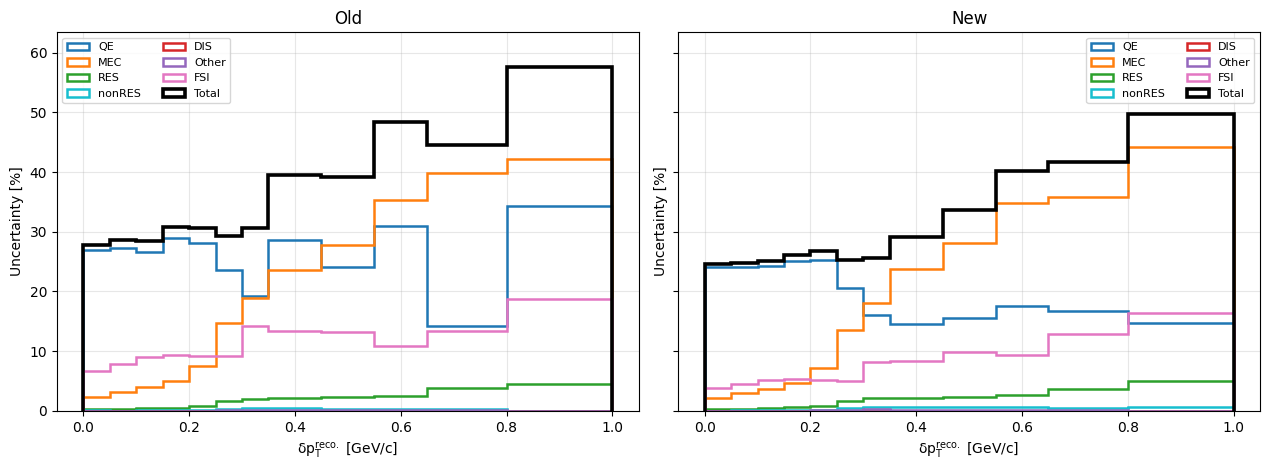

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__distributed__rate__tki-del_alpha.png


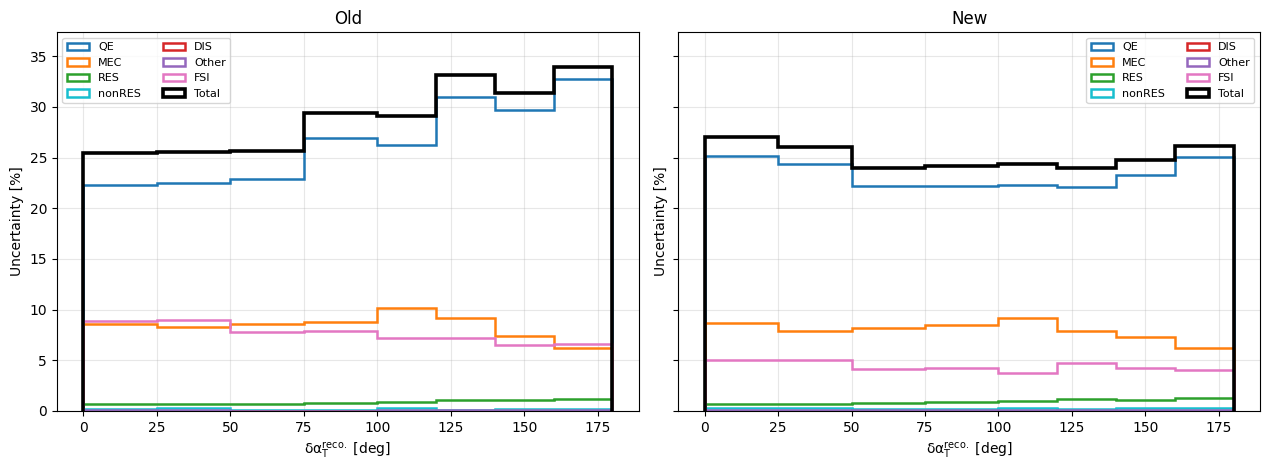

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__distributed__rate__tki-del_phi.png


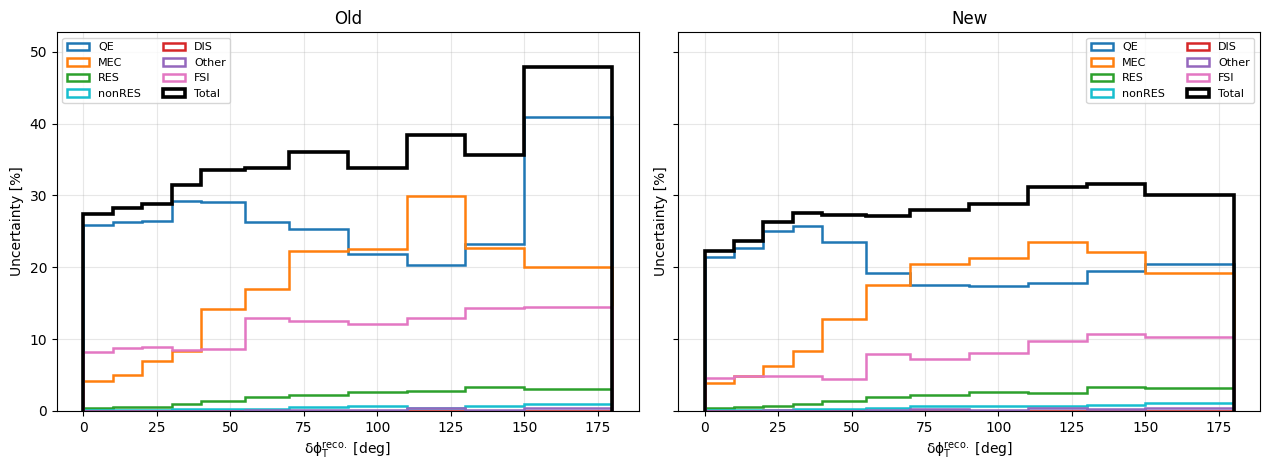

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__distributed__xsec__integrated.png


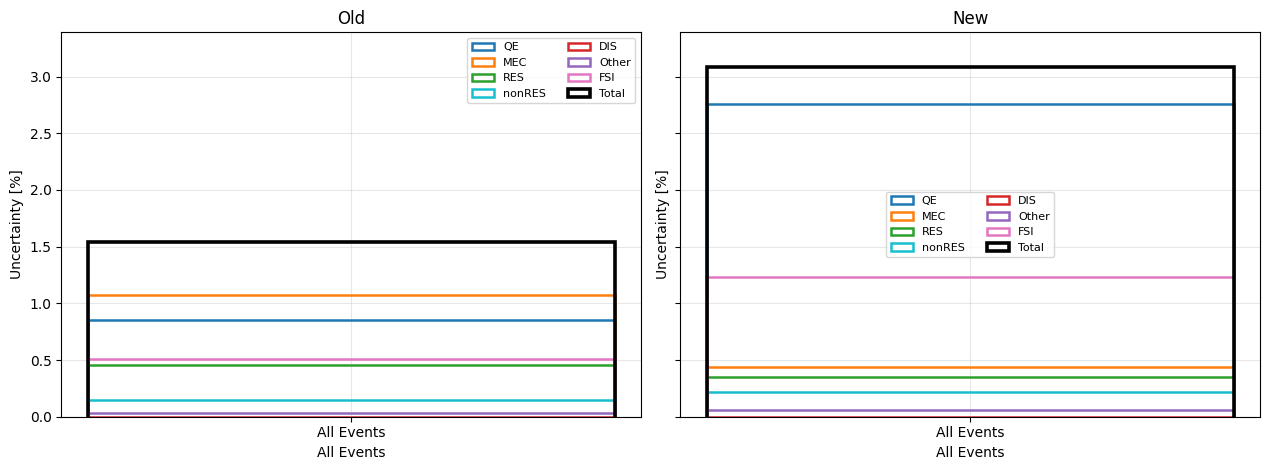

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__distributed__xsec__tki-del_Tp.png


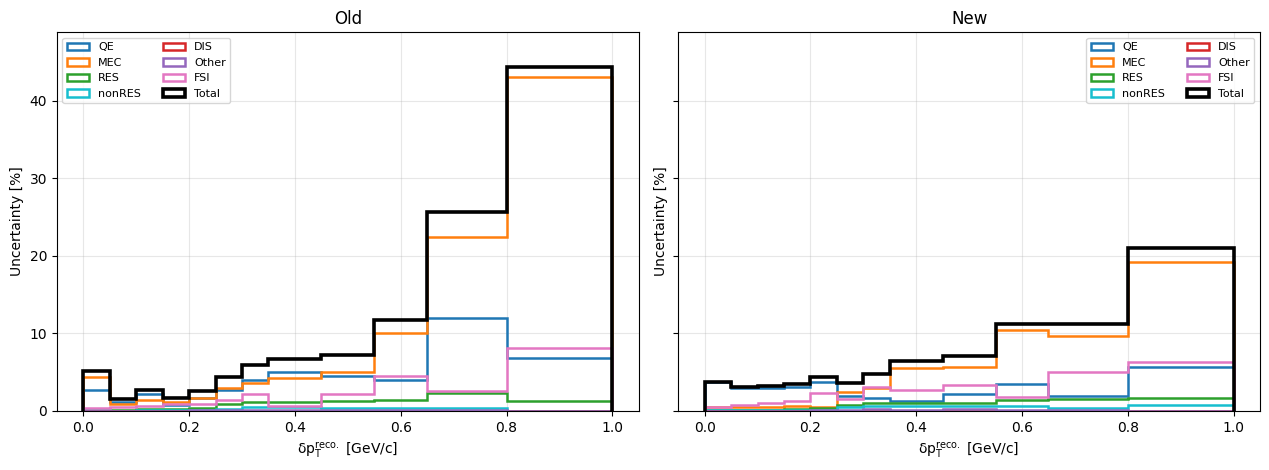

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__distributed__xsec__tki-del_alpha.png


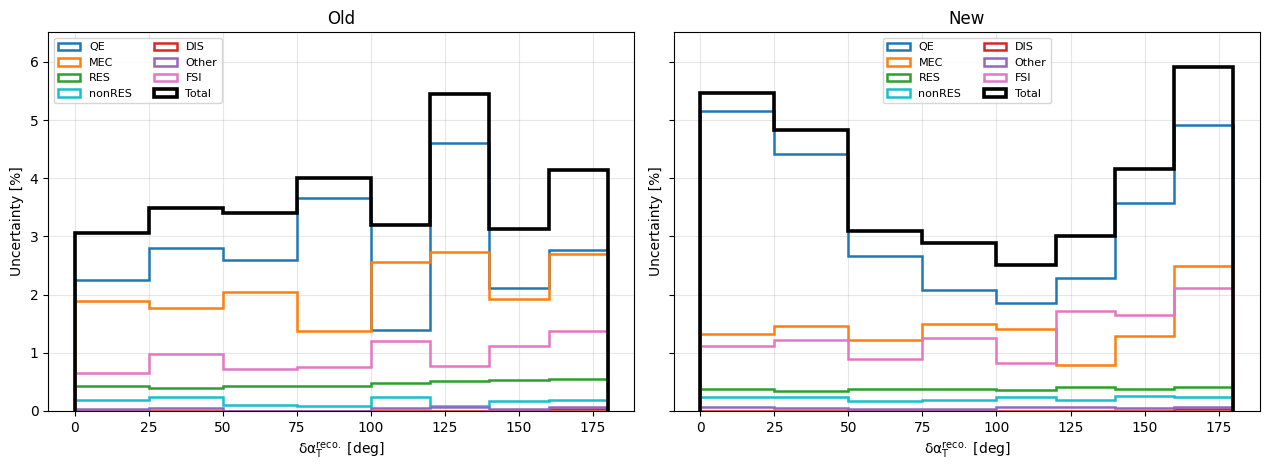

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec2_mode_totals__distributed__xsec__tki-del_phi.png


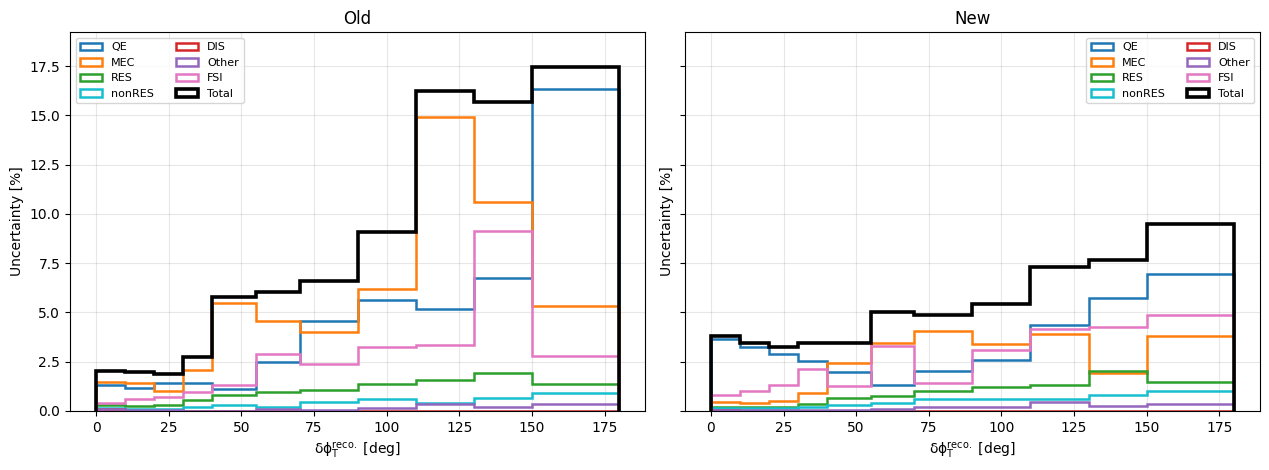

In [47]:
print("Distributed assignment examples (newer):")
if "Other" in groups_new and "integrated" in groups_new["Other"]:
    seen = {}
    for kn, _ in iter_knob_cov_fracs(groups_new["Other"]["integrated"], "xsec"):
        seen.setdefault(assign_other_mode_knob_to_bucket(kn), []).append(kn)
    for dest, kns in sorted(seen.items()):
        print(f"  Other→{dest}: {len(kns)} knobs (e.g. {kns[0]})")
if "Ar23p" in groups_new and "integrated" in groups_new["Ar23p"]:
    seen = {}
    for kn, _ in iter_knob_cov_fracs(groups_new["Ar23p"]["integrated"], "xsec"):
        seen.setdefault(assign_ar23p_knob_to_mode(kn), []).append(kn)
    for dest, kns in sorted(seen.items()):
        print(f"  Ar23p→{display_mode_name(dest)}: {len(kns)} knobs (e.g. {kns[0]})")


def _ymax_from_covs(mats) -> float:
    vals = []
    for m in mats:
        if m is None:
            continue
        w = frac_unc_pct(m)
        if w.size:
            vals.append(float(np.nanmax(w)))
    return max(vals) if vals else 1.0


def _set_shared_ylim(axes, ymax: float, pad: float = 1.1):
    ytop = max(ymax * pad, 1e-6)
    for ax in axes:
        ax.set_ylim(0.0, ytop)


def _section2_compare(distribute_ar23p: bool, tag: str):
    mode_order = DISTRIBUTED_MODE_ORDER if distribute_ar23p else MODE_ORDER
    totals_fn = (
        mode_totals_ar23p_distributed if distribute_ar23p else mode_totals_ar23p_standalone
    )
    eras = [
        ("old", groups_old, ERA_LABELS["old"]),
        ("new", groups_new, ERA_LABELS["new"]),
    ]

    for kind in COV_TYPES:
        for slug in plot_vars:
            vc = vc_by.get(slug)
            mts = [totals_fn(groups, slug, kind) for _k, groups, _lab in eras]
            ymax = 0.0
            for mt in mts:
                mats = [mt[m] for m in mode_order if m in mt]
                mats.append(sum_cov_fracs(list(mt.values())))
                ymax = max(ymax, _ymax_from_covs(mats))

            fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), sharey=True)
            for ax, mt, (_era_key, _groups, era_lab) in zip(axes, mts, eras):
                plot_mode_frac_unc(
                    ax, mt, vc=vc, kind=kind, mode_order=mode_order,
                )
                ax.set_title(era_lab, fontsize=12)
            _set_shared_ylim(axes, ymax)
            fig.tight_layout()
            if SAVE_FIGS:
                out = OUT_DIR / f"sec2_mode_totals__{tag}__{kind}__{slug}.png"
                fig.savefig(out, dpi=FIG_DPI, bbox_inches="tight")
                print("wrote", out)
            plt.show()


_section2_compare(distribute_ar23p=False, tag="standalone")
_section2_compare(distribute_ar23p=True, tag="distributed")


## 3. Total GENIE + top 10 knobs

Rank by **New** integrated fractional uncertainty (binned families collapsed).
Both subplots follow that New ranking: take **10 New** knobs (skip `LFGToHF`),
then always add **SuSAToVal** and **SuSAToMar** if not already included.
Old shows best-match knobs only (fewer when New has no counterpart, or when
`MFP* N` / `FrINCL*`+`FrG4*` collapse to one `MFP N` / `FrInel N`).
Legends: **Old names on Old**, **New names on New**. Matrices are skipped.
Matched knobs share **matching colors** across the two panels.



[rate] New top 10 → Old matches 9:
  total GENIE Old:                                28.036%
  total GENIE New:                                23.236%
  New:
     1. ZExp                                      12.276%
     2. QEIntf                                    11.400%
     3. RPA QE                                     8.171%
     4. LFGToSF                                    7.854%
     5. NormCCMEC                                  7.045%
     6. HFToCRPA                                   4.011%
     7. SuSAToVal                                  2.256%
     8. SuSAToMar                                  2.036%
     9. MFPLoE N                                   2.000%
    10. MFPM1E N                                   1.698%
  Old (matched):
     1. ZExp                                      19.804%
     2. QEIntf                                    11.305%
     3. RPA QE                                     8.284%
     4. LFGToSF                                    8.316%
     5. Norm

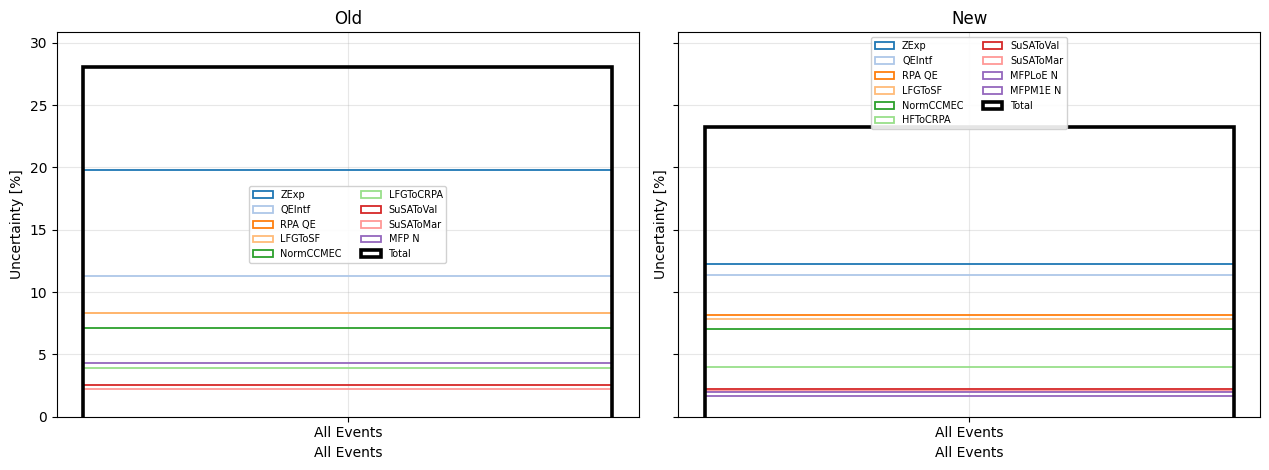

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec3_top10__rate__tki-del_Tp.png


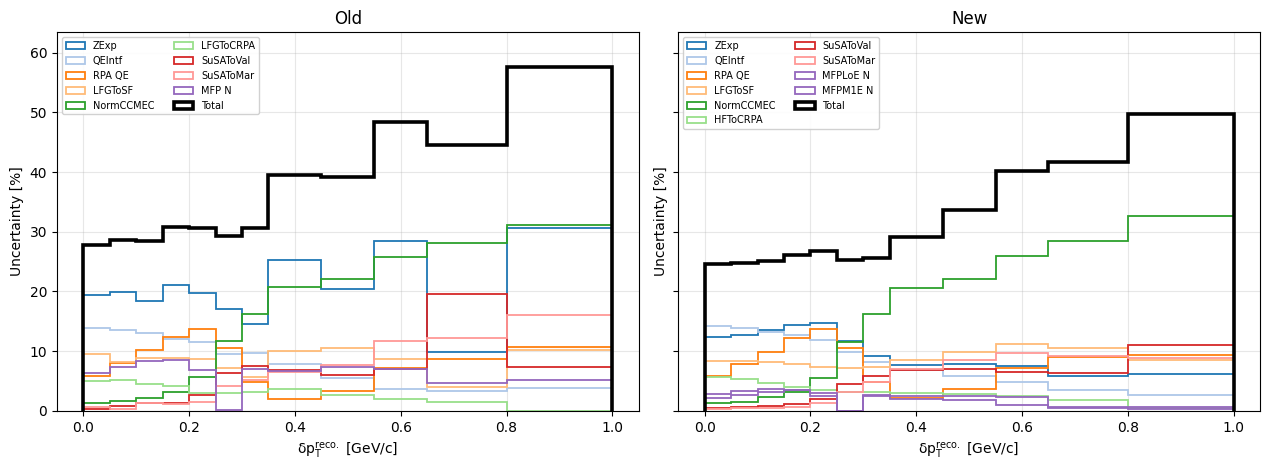

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec3_top10__rate__tki-del_alpha.png


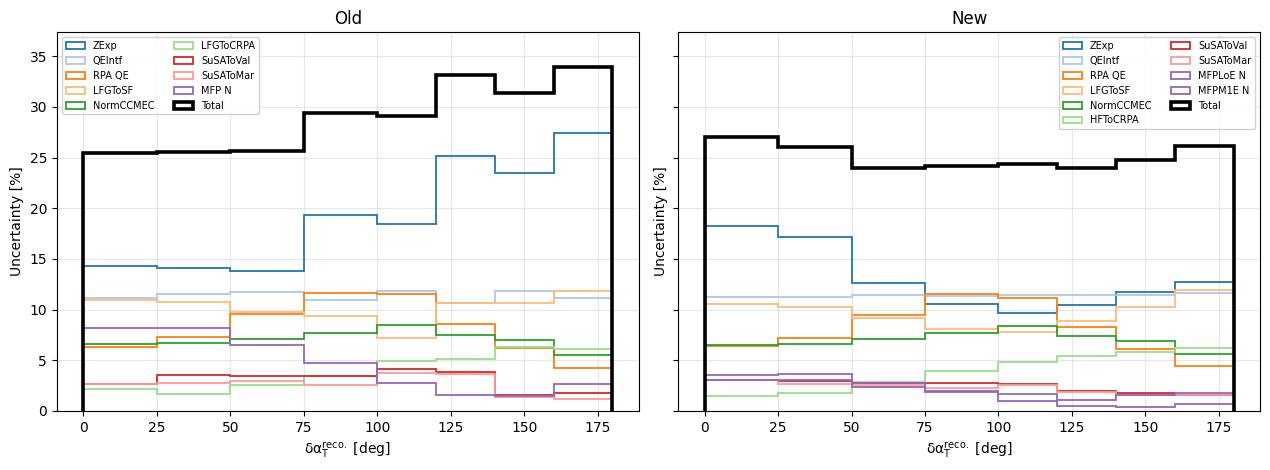

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec3_top10__rate__tki-del_phi.png


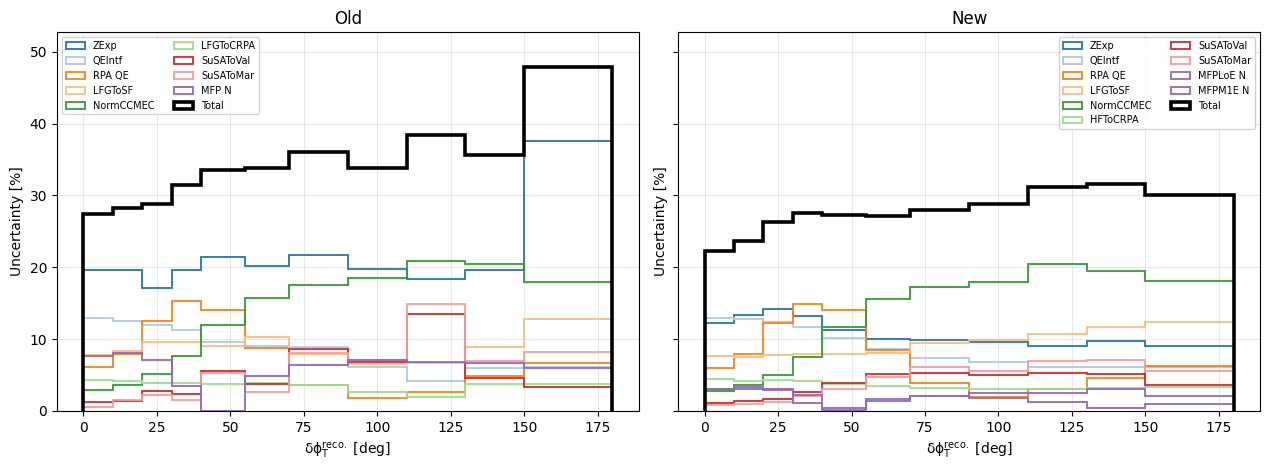


[xsec] New top 12 → Old matches 9:
  total GENIE Old:                                 1.537%
  total GENIE New:                                 3.082%
  New:
     1. ZExp                                       1.684%
     2. QEIntf                                     1.332%
     3. LFGToSF                                    1.151%
     4. RPA QE                                     1.037%
     5. MFPM1E N                                   0.679%
     6. MFPLoE N                                   0.653%
     7. HFToCRPA                                   0.636%
     8. FrINCLM1E N                                0.443%
     9. FrG4LoE N                                  0.367%
    10. FrINCLLoE N                                0.346%
    11. SuSAToVal                                  0.212%
    12. SuSAToMar                                  0.193%
  Old (matched):
     1. ZExp                                       0.425%
     2. QEIntf                                     0.312%
     3. LFGT

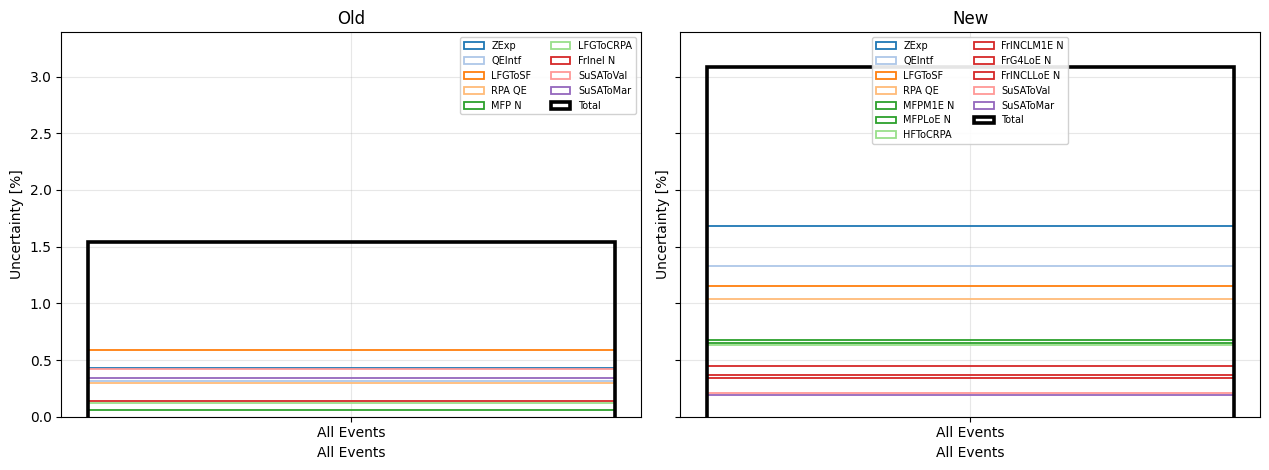

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec3_top10__xsec__tki-del_Tp.png


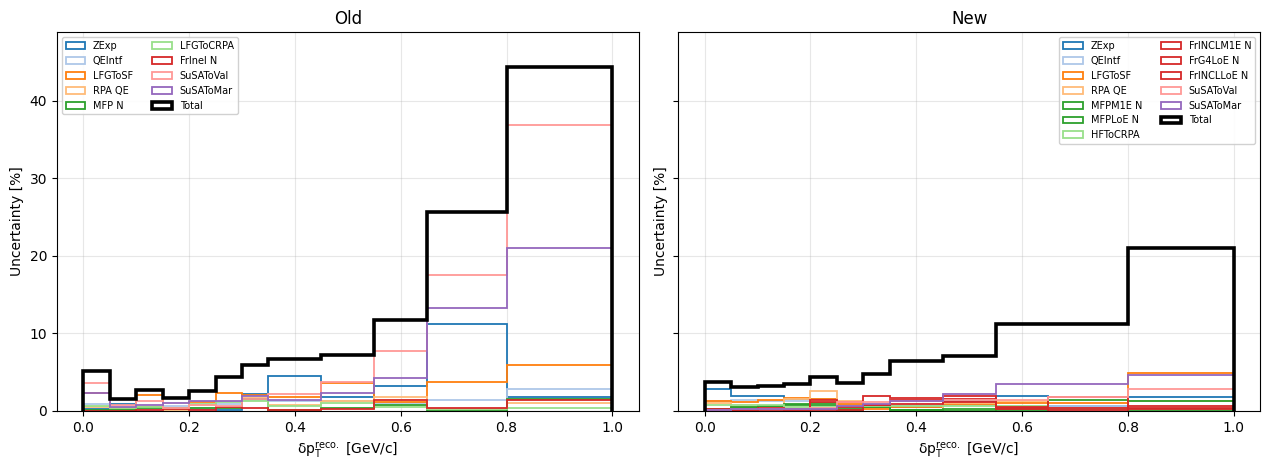

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec3_top10__xsec__tki-del_alpha.png


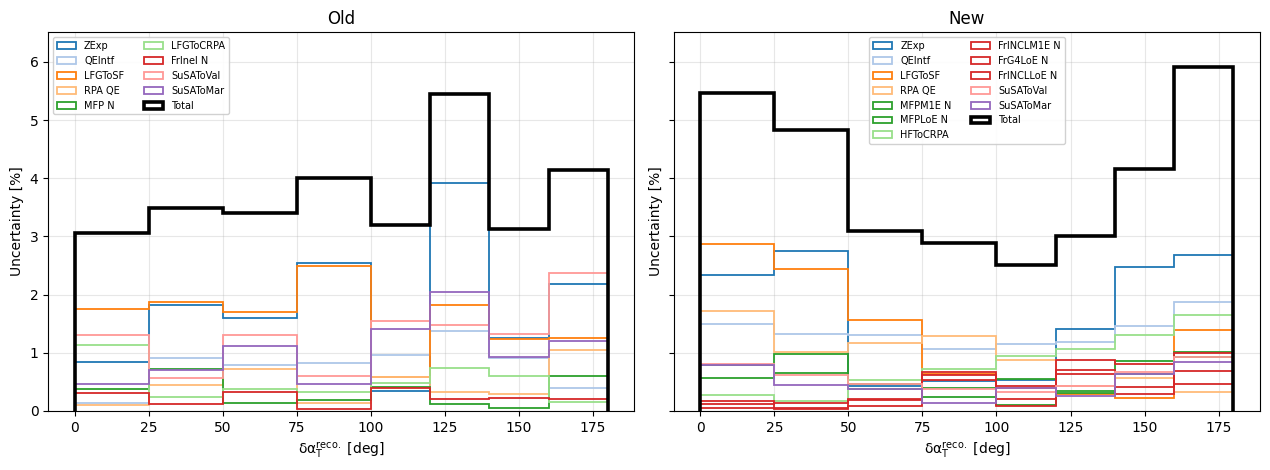

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_comparison/sec3_top10__xsec__tki-del_phi.png


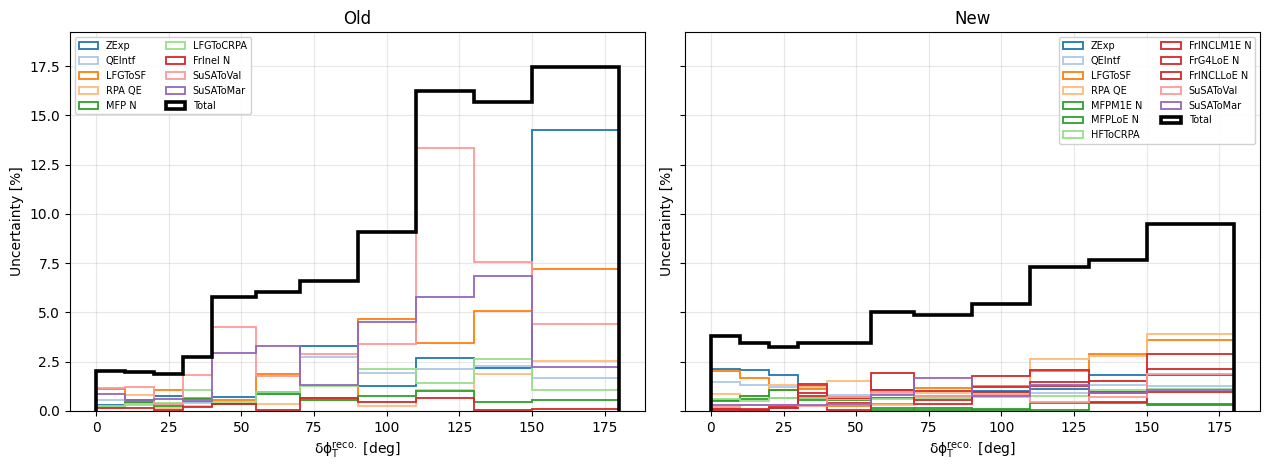

In [48]:
# Legend family names: align old-era labels with new; tidy new MECResponse labels.
_LEGEND_REMAP_OLD = {
    "multisigma SF": "LFGToSF",
    "multisigma CRPA": "LFGToCRPA",
    "MvA": "ZExp",
    "MEC Valencia": "SuSAToVal",
    "MEC Martini": "SuSAToMar",
    "SBNNuSyst EDepFSI FrInel pi": "FrInel pi",
    "SBNNuSyst INT QEIntf": "QEIntf",
}
_LEGEND_REMAP_NEW = {
    "SuSAToVal MECResponse": "SuSAToVal",
    "SuSAToMar MECResponse": "SuSAToMar",
}

# New family (after new remap) → Old legend family. Specials handled below.
_NEW_FAM_TO_OLD_LEGEND = {
    "HFToCRPA": "LFGToCRPA",
    "LFGToSF": "LFGToSF",
    "ZExp": "ZExp",
    "QEIntf": "QEIntf",
    "SuSAToVal": "SuSAToVal",
    "SuSAToMar": "SuSAToMar",
    "NormCCMEC": "NormCCMEC",
    "RPA QE": "RPA QE",
    "MFP N": "MFP N",
    "FrInel N": "FrInel N",
}


def _remap_legend_family(name: str, era: str) -> str:
    table = _LEGEND_REMAP_OLD if era == "old" else _LEGEND_REMAP_NEW
    return table.get(name, name)


def _family_disp(key: str, era: str) -> str:
    return _remap_legend_family(strip_mode_prefix(key), era)


def _index_by_family(parts: dict, era: str) -> dict:
    """Map remapped family label → first full ``mode/family`` key."""
    out = {}
    for k in parts:
        out.setdefault(_family_disp(k, era), k)
    return out


def _old_legend_for_new_family(fam: str):
    """Old legend name for a New family, or ``None`` to skip on Old."""
    if fam == "LFGToHF":
        return None
    # Energy-binned MFP_* N → single Old MFP N
    if fam.startswith("MFP") and fam.endswith(" N"):
        return "MFP N"
    # New INCL / G4 nucleon FSI → single Old FrInel N
    if fam.startswith("FrINCL") or fam.startswith("FrG4"):
        return "FrInel N"
    return _NEW_FAM_TO_OLD_LEGEND.get(fam, fam)


def _top_new_keys(int_parts_new: dict, n: int) -> list:
    """New ranking; skip LFGToHF; stop at ``n`` New knobs."""
    ranked = top_n_knobs_by_integrated(
        int_parts_new, int_parts_new, n=len(int_parts_new),
    )
    out = []
    for new_key in ranked:
        if _family_disp(new_key, "new") == "LFGToHF":
            continue
        out.append(new_key)
        if len(out) >= n:
            break
    return out


_ALWAYS_SHOW_NEW = ("SuSAToVal", "SuSAToMar")


def _append_always_show_new(new_keys: list, int_parts_new: dict) -> list:
    """Append SuSAToVal / SuSAToMar if missing from the New top list."""
    by_fam = _index_by_family(int_parts_new, "new")
    present = {_family_disp(k, "new") for k in new_keys}
    out = list(new_keys)
    for fam in _ALWAYS_SHOW_NEW:
        if fam in present:
            continue
        key = by_fam.get(fam)
        if key is None:
            print(f"  warn: New missing always-show '{fam}'")
            continue
        out.append(key)
        present.add(fam)
    return out


def _old_entries_for_new_keys(new_keys: list, int_parts_old: dict) -> list:
    """Map New keys → unique Old ``(legend, old_key)`` (collapses MFP / FrInel)."""
    old_by_fam = _index_by_family(int_parts_old, "old")
    used = set()
    entries = []
    for new_key in new_keys:
        fam_new = _family_disp(new_key, "new")
        legend = _old_legend_for_new_family(fam_new)
        if legend is None or legend in used:
            continue
        old_key = old_by_fam.get(legend)
        if old_key is None:
            print(f"  warn: no Old match for New '{fam_new}' → '{legend}', skip")
            continue
        used.add(legend)
        entries.append((legend, old_key))
    return entries


eras = [
    ("old", groups_old, ERA_LABELS["old"]),
    ("new", groups_new, ERA_LABELS["new"]),
]

for kind in COV_TYPES:
    int_parts_by_era = {}
    total_int_by_era = {}
    for era_key, groups, era_lab in eras:
        int_parts_by_era[era_key] = all_knob_parts(
            groups, "integrated", kind, distribute_ar23p=False, collapse_binned=True,
        )
        mt_int = mode_totals_ar23p_standalone(groups, "integrated", kind)
        total_int_by_era[era_key] = sum_cov_fracs(list(mt_int.values()))

    new_keys = _top_new_keys(int_parts_by_era["new"], n=TOP_N_KNOBS)
    new_keys = _append_always_show_new(new_keys, int_parts_by_era["new"])
    old_entries = _old_entries_for_new_keys(new_keys, int_parts_by_era["old"])

    # Shared colors by Old↔New correspondence (Old legend name as match id).
    _palette = plt.cm.tab20(np.linspace(0, 1, 20))
    color_by_corr = {}
    for new_key in new_keys:
        fam = _family_disp(new_key, "new")
        corr = _old_legend_for_new_family(fam) or fam
        if corr not in color_by_corr:
            color_by_corr[corr] = _palette[len(color_by_corr) % len(_palette)]
    colors_new = {}
    for new_key in new_keys:
        fam = _family_disp(new_key, "new")
        corr = _old_legend_for_new_family(fam) or fam
        colors_new[fam] = color_by_corr[corr]
    colors_old = {
        legend: color_by_corr[legend]
        for legend, _ in old_entries
        if legend in color_by_corr
    }

    print(f"\n[{kind}] New top {len(new_keys)} → Old matches {len(old_entries)}:")
    print(
        f"  total GENIE Old:{'':30s}  "
        f"{integrated_frac_unc_pct(total_int_by_era['old']):6.3f}%"
    )
    print(
        f"  total GENIE New:{'':30s}  "
        f"{integrated_frac_unc_pct(total_int_by_era['new']):6.3f}%"
    )
    print("  New:")
    for i, new_key in enumerate(new_keys, 1):
        fam = _family_disp(new_key, "new")
        pct = integrated_frac_unc_pct(int_parts_by_era["new"][new_key])
        print(f"    {i:2d}. {fam:40s}  {pct:6.3f}%")
    print("  Old (matched):")
    for i, (legend, old_key) in enumerate(old_entries, 1):
        pct = integrated_frac_unc_pct(int_parts_by_era["old"][old_key])
        print(f"    {i:2d}. {legend:40s}  {pct:6.3f}%")

    for slug in plot_vars:
        vc = vc_by.get(slug)
        prepared = []
        ymax = 0.0
        for era_key, groups, era_lab in eras:
            parts = all_knob_parts(
                groups, slug, kind, distribute_ar23p=False, collapse_binned=True,
            )
            mt = mode_totals_ar23p_standalone(groups, slug, kind)
            total = sum_cov_fracs(list(mt.values()))
            show_parts = {}
            ordered = []
            if era_key == "new":
                for new_key in new_keys:
                    if new_key not in parts:
                        continue
                    legend = _family_disp(new_key, "new")
                    show_parts[legend] = parts[new_key]
                    ordered.append(legend)
                color_map = colors_new
            else:
                for legend, old_key in old_entries:
                    if old_key not in parts:
                        continue
                    show_parts[legend] = parts[old_key]
                    ordered.append(legend)
                color_map = colors_old
            prepared.append((era_lab, show_parts, total, ordered, color_map))
            ymax = max(ymax, _ymax_from_covs(list(show_parts.values()) + [total]))

        fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), sharey=True)
        for ax, (era_lab, show_parts, total, ordered, color_map) in zip(axes, prepared):
            plot_frac_unc_breakdown(
                ax, show_parts, total, vc=vc,
                kind=kind,
                ordered_keys=ordered,
                show_pct_in_legend=False,
                legend_knob_only=True,
                colors=color_map,
            )
            ax.set_title(era_lab, fontsize=12)
        _set_shared_ylim(axes, ymax)
        fig.tight_layout()
        if SAVE_FIGS:
            out = OUT_DIR / f"sec3_top{TOP_N_KNOBS}__{kind}__{slug}.png"
            fig.savefig(out, dpi=FIG_DPI, bbox_inches="tight")
            print("wrote", out)
        plt.show()
